In [1]:
import pandas as pd

from geoai.utils_ds.PreProcessingOps import PreProcessingOperations
from geoai.utils_ds.VisualizeOps import VisualizeOperations
from sklearn.linear_model import LogisticRegression
from geoai.utils_ml.ModelOps import ModelOperations

pre_ops = PreProcessingOperations()
vis_ops = VisualizeOperations()
model_ops = ModelOperations()

In [2]:
X_train = pd.read_csv("csv_files/X_train_fe.csv")
X_test = pd.read_csv("csv_files/X_test_fe.csv")
y_train = pd.read_csv("csv_files/y_train.csv")
y_test = pd.read_csv("csv_files/y_test.csv")
X_train.head(1)

,BLUE,GREEN,RED,NIR,SWIR,NDVI,NDBI,REI,BLUE^2,BLUE GREEN,...,SWIR REI,NDVI^2,NDVI NDBI,NDVI REI,NDBI^2,NDBI REI,REI^2,NDVI_bin_non_veg,NDVI_bin_veg,NDVI_dis_encoded
0,373.5,519.5,389.0,3034.0,1991.0,0.772714,-0.207562,0.002342,139502.25,194033.25,...,4.661945,0.597087,-0.160386,0.001809,0.043082,-0.000486,0.000005,0,1,2


In [3]:
# scale the data
X_train_fe_scaled, X_test_fe_scaled = pre_ops.scale_to_minmax(X_train, X_test)
X_train_fe_scaled.head(1)

,BLUE,GREEN,RED,NIR,SWIR,NDVI,NDBI,REI,BLUE^2,BLUE GREEN,...,SWIR REI,NDVI^2,NDVI NDBI,NDVI REI,NDBI^2,NDBI REI,REI^2,NDVI_bin_non_veg,NDVI_bin_veg,NDVI_dis_encoded
0,0.01238,0.020718,0.023453,0.615321,0.141552,0.941447,0.12174,0.883081,0.001893,0.002796,...,0.903032,0.882198,0.253733,0.844985,0.404388,0.207416,0.779808,0.0,1.0,1.0


d:\Projects\GEOAI\GeoAI-ISPRS-SS\geoai-env\Lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


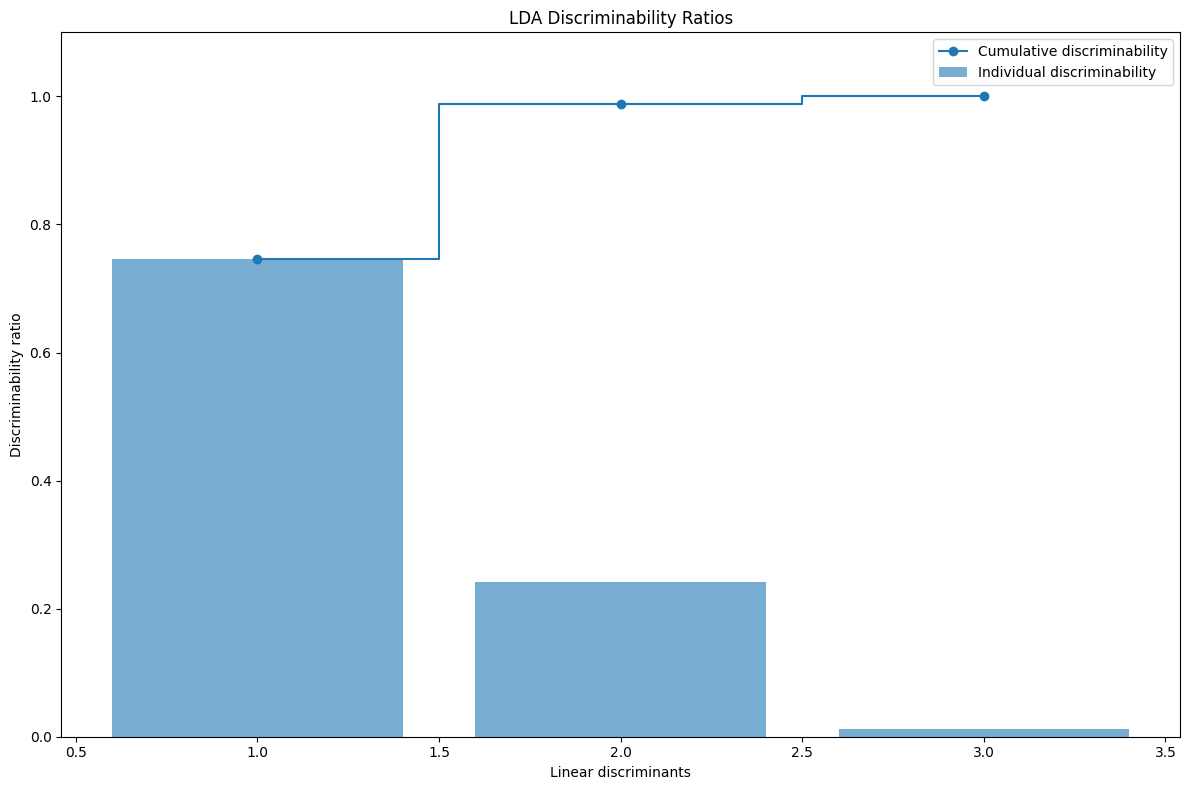

array([0.74583247, 0.98790858, 1.        ])

In [4]:
explained_variance_ratio, cumulative_discriminability = (
    pre_ops.compute_discriminability_ratios(X_train_fe_scaled, y_train)
)

vis_ops.plot_discriminality_ratio(
    explained_variance_ratio, cumulative_discriminability
)
cumulative_discriminability

In [6]:
# apply_lda using 3 components
X_train_lda, X_test_lda = pre_ops.apply_lda(
    X_train_fe_scaled, y_train, X_test_fe_scaled, n_components=3
)    

d:\Projects\GEOAI\GeoAI-ISPRS-SS\geoai-env\Lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [12]:
# fit the model using the pca data
lr = LogisticRegression(solver='lbfgs', max_iter=1000)
lr.fit(X_train_lda, y_train.values.ravel())

# predict the validation set
y_train_pred = lr.predict(X_train_lda)
y_pred_test = lr.predict(X_test_lda)

# calculate the accuracy
print(f"Train Accuracy: {model_ops.calculate_classification_accuracy(y_train, y_train_pred)}")
print(f"Test Accuracy: {model_ops.calculate_classification_accuracy(y_test, y_pred_test)}")

Train Accuracy: (0.937467700258398, 0.9378469707503807, 0.937467700258398, 0.9375970119680029)
Test Accuracy: (0.9256198347107438, 0.9263747494029527, 0.9256198347107438, 0.9258429757018053)


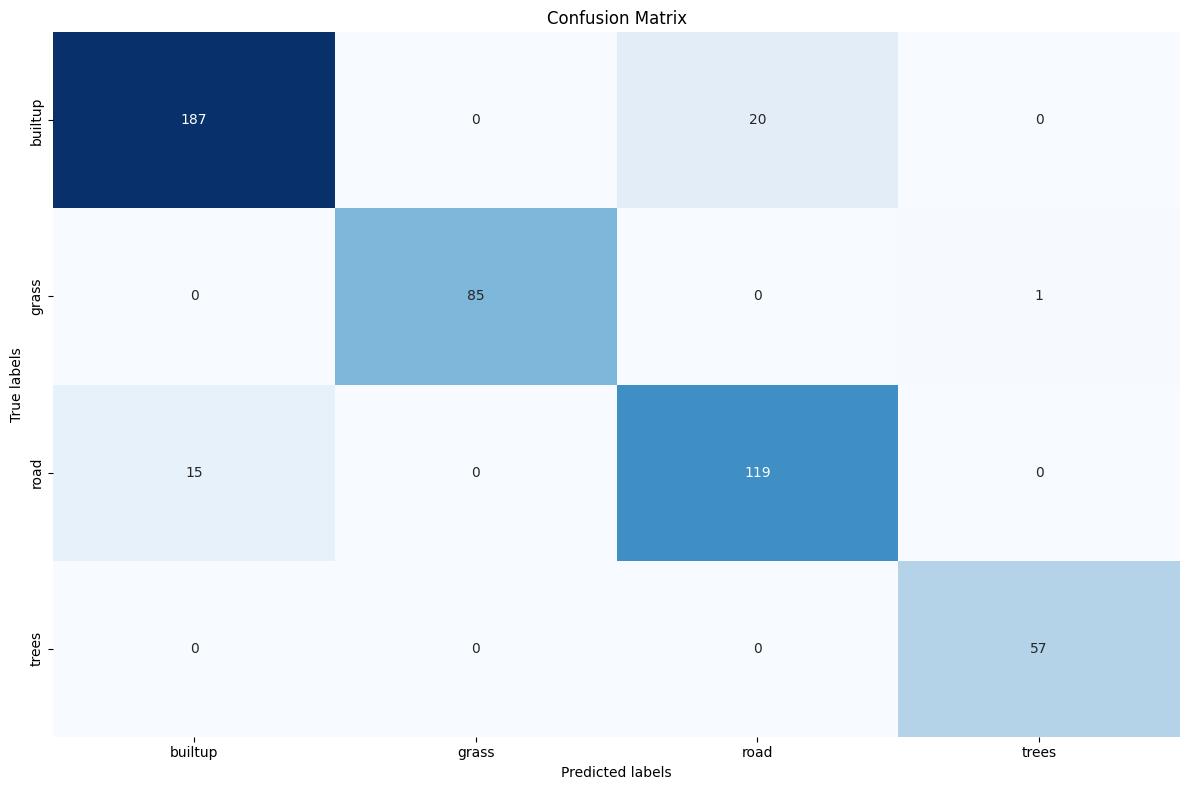

In [13]:
label_mapping = {0: 'builtup', 1: 'grass', 2: 'road', 3: 'trees'}
class_names_str = [label_mapping[label] for label in lr.classes_]
vis_ops.plot_confusion_matrix(y_test, y_pred_test, class_names_str)

END